This attempt uses a RandomForestClassifier instead of a DecisionTreeClassifier

In [1]:
import os
import sys
import pandas as pd
import geopandas as gpd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

sys.path.append("../utils")

import config

pd.set_option("display.max_columns", None)


In [2]:
inspections_buffered_buildings_landcover = gpd.read_file(
    "/capstone/wildfire_prep/data/inspections_data/cleaned_status_with_id/inspections_buffered_buildings_landcover.geojson"
)


In [3]:
# landcover codes are coming in with the format '582.0', so let's make them integers
inspections_buffered_buildings_landcover["maj_landcover_code"] = (
    inspections_buffered_buildings_landcover["maj_landcover_code"].astype("Int64")
)

# make ZIP code an integer too
inspections_buffered_buildings_landcover["zip_code"] = (
    inspections_buffered_buildings_landcover["zip_code"].astype("Int64")
)

inspections_buffered_buildings_landcover.dtypes


system_created        datetime64[ms]
inspection_status             object
latitude                     float64
longitude                    float64
address_number                object
street                        object
apt_number                    object
city                          object
county                        object
state                         object
zip_code                       Int64
country                       object
address_full                  object
date                  datetime64[ms]
inspection_date               object
structure_type                object
year                           int32
address_id                     int32
maj_landcover_code             Int64
geometry                    geometry
dtype: object

In [4]:
data = inspections_buffered_buildings_landcover.drop(
    columns=[
        "system_created",
        "latitude",
        "longitude",
        "address_number",
        "street",
        "apt_number",
        "city",
        "county",
        "state",
        "country",
        "address_full",
        "date",
        "inspection_date",
        "geometry",
        'zip_code',
        'year',
        'address_id'
    ]
)

data.head()


,inspection_status,structure_type,maj_landcover_code
0,Compliant,School,582
1,Compliant,School,582
2,Compliant,School,582
3,Compliant,School,582
4,Compliant,School,582


In [5]:
categoricals = data.select_dtypes(include=["object"])

for col in categoricals:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

data.head()


,inspection_status,structure_type,maj_landcover_code
0,0,11,582
1,0,11,582
2,0,11,582
3,0,11,582
4,0,11,582


In [6]:
X = data.drop("inspection_status", axis=1)
y = data["inspection_status"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)


In [7]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9953853253345639


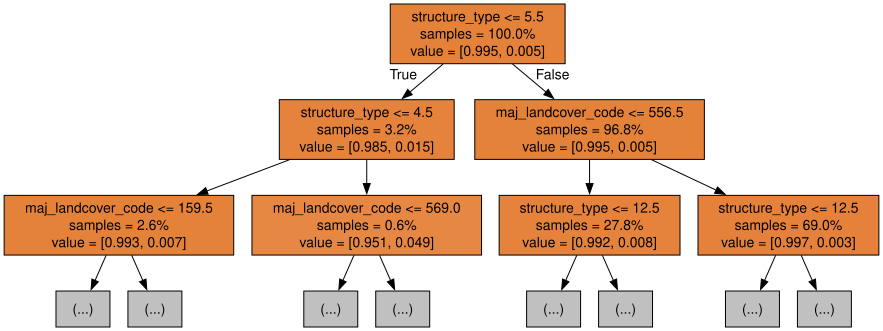

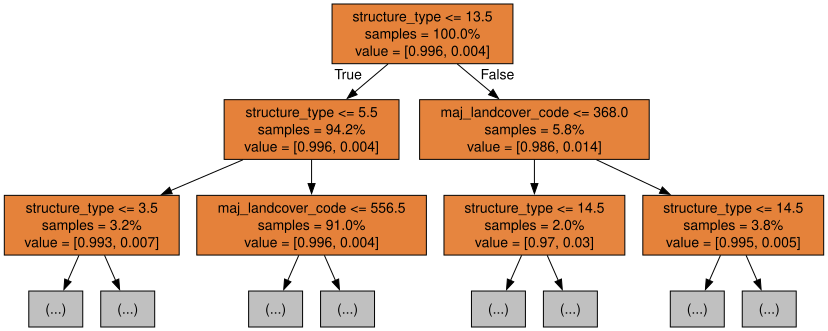

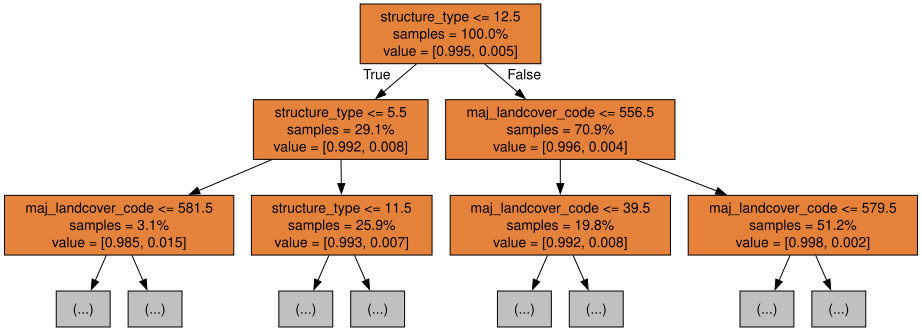

In [8]:
# Export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(
        tree,
        feature_names=X_train.columns,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True,
    )
    graph = graphviz.Source(dot_data)
    display(graph)


In [9]:
# param_dist = {"n_estimators": randint(50, 500), "max_depth": randint(1, 20)}

# # Create a random forest classifier
# rf = RandomForestClassifier()

# # Use random search to find the best hyperparameters
# rand_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5)

# # Fit the random search object to the data
# rand_search.fit(X_train, y_train)


In [30]:
param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": randint(1, 20),
    "class_weight": [None, "balanced", "balanced_subsample"],
}

rf = RandomForestClassifier(random_state=42)

rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="precision",  # <-- optimize for precision
    refit=True,  # after search, refit on the whole train set
)

rand_search.fit(X_train, y_train)

print("Best precision: ", rand_search.best_score_)
print("Best params:    ", rand_search.best_params_)


/Users/ryangreen/.conda/envs/prg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ryangreen/.conda/envs/prg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ryangreen/.conda/envs/prg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/

Best precision:  0.4
Best params:     {'class_weight': None, 'max_depth': 19, 'n_estimators': 189}


In [31]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print("Best hyperparameters:", rand_search.best_params_)


Best hyperparameters: {'class_weight': None, 'max_depth': 19, 'n_estimators': 189}


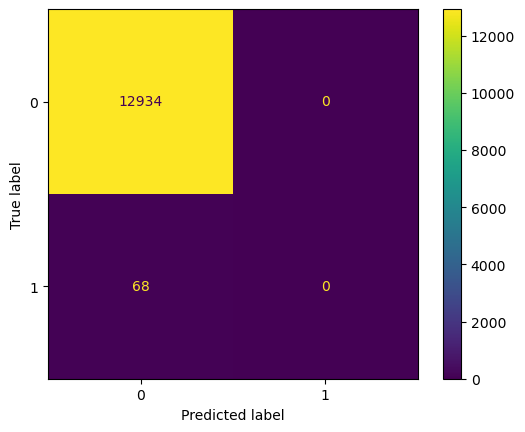

In [32]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();


In [33]:
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.9947700353791724
Precision: 0.0
Recall: 0.0


/Users/ryangreen/.conda/envs/prg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


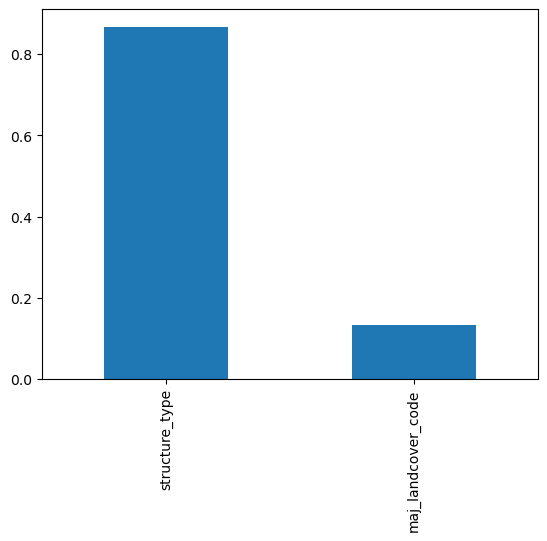

In [34]:
# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(
    best_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();
